## Phase 1: Run Linear Probes on Single Datasets: LLaMA-2-7B on Bioasq (2k)

* [Done] Variations: SE -> Acc; SE -> SE; Acc -> Acc. <br>
* [Done] Across all layers for both SLT and TBG tokens. **Goal: find best layers**. <br>
* [Done] Binarization (best split via regression forest). <br>
* [Done] Save log of test metrics for visualization.
* [Done] Take some time to alter the llama codes for keeping residuals and attention outputs.

In [5]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy
import seaborn as sns

import wandb
# os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240422_125709-vjb2jtnx/files')  # path for llama2-7b on trivia_qa (2k)
# os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240501_122139-p2dmjswm/files')  # path for llama2-7b on nq (3.61k) - we may take the first 2k.
# os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240320_140822-qlf5m8bq/files')  # path for llama2-7b on squad (2k) - not use
os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240502_214227-xntoccm9/files') # path for llama2-7b on bioasq (2k)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Utility Functions

In [6]:
# Read training generated embeddings
f = open('validation_generations.pkl', 'rb')
generations = pickle.load(f)
f.close()

# Read uncertainty measures (p-true, predictive/semantic uncertainties)
g = open('uncertainty_measures.pkl', 'rb')
measures = pickle.load(g)
g.close()

In [7]:
entropy = torch.tensor(measures['uncertainty_measures']['cluster_assignment_entropy']).to(torch.float32)  # replace semantic_entropy with cluster_assignment_entropy
print(entropy.shape, entropy)

torch.Size([2000]) tensor([2.1640, 2.3026, -0.0000,  ..., 0.6390, 2.1640, 0.9404])


In [8]:
# Define LR and MLP model structures (LR)
import torch
import torch.nn as nn
from torch.nn import Linear, ReLU, Dropout, BatchNorm1d, Sigmoid
from sklearn.linear_model import LogisticRegression, LinearRegression

class MLP(nn.Module):
    def __init__(self, in_dim, hid_dims, out_dim=1, dropout=0.5):
        super(MLP, self).__init__()
        layers = []
        
        if isinstance(hid_dims, int):
            layer_dims = [in_dim] + [hid_dims] * 2
        elif isinstance(hid_dims, list):
            layer_dims = [in_dim] + hid_dims
        else:
            raise ValueError("hid_dims must be either an integer or a list of integers")
        
        for i in range(len(layer_dims) - 1):
            layers.append(Linear(layer_dims[i], layer_dims[i+1]))
            layers.append(BatchNorm1d(layer_dims[i+1]))
            layers.append(ReLU())
            layers.append(Dropout(dropout))

        layers.append(Linear(layer_dims[-1], out_dim))        
        self.layers = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.layers(x)


class MLPClassifier(MLP):
    def __init__(self, in_dim, hid_dims, dropout):
        super().__init__(in_dim, hid_dims, out_dim=1, dropout=dropout)

    def forward(self, x):
        x = super().forward(x)
        x = torch.sigmoid(x) 
        return x

## Use Linear Probe for Predicting Semantic Entropy 

We experiment with the 'Last Input Token before Generation' first.

We train simple MLPs (4 hidden layers, 100 epochs w/ early stopping) on the token embeddings from each layer on _semantic entropy_ scores. 

In this section, we only prepare datasets for later transfer learning tasks.

In [9]:
tok_bef_gen_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
# Originally float64
entropy = entropy.to(torch.float32)
ca_entropy = entropy.clone()
mean = ca_entropy.mean()
std = ca_entropy.std()
print(ca_entropy.min(), ca_entropy.max(), mean, std)
ca_entropy = (ca_entropy - mean) / std

print(tok_bef_gen_dataset.shape, ca_entropy.shape)

tensor(-0.) tensor(2.3026) tensor(1.3681) tensor(0.7883)
torch.Size([2000, 33, 4096]) torch.Size([2000])


### Explore Token before First Generated Token (TBG)

We experment layer-by-layer.

In [10]:
tok_bef_gen_layered_datasets = tok_bef_gen_dataset.transpose(0, 1)
print(tok_bef_gen_layered_datasets.shape)

torch.Size([33, 2000, 4096])


In [11]:
# Make batched inputs and dataloaders (one for each layer)
from torch.utils.data import DataLoader, Subset, TensorDataset, ConcatDataset

from sklearn.model_selection import train_test_split

total_size = 2000  # Number of samples
batch_size = 32

def create_dataloaders(tok_bef_gen_layered_datasets, semantic_entropy, total_size, batch_size, set_seed=False, val_test_splits=[0.2, 0.1]):
    if set_seed:
        torch.manual_seed(42)
    
    indices = torch.randperm(total_size)
    test_size = int(total_size * val_test_splits[1])
    valid_size = int((total_size - test_size) * val_test_splits[0])
    train_size = total_size - test_size - valid_size

    train_indices = indices[:train_size]
    valid_indices = indices[train_size:train_size + valid_size]
    test_indices = indices[train_size + valid_size:]

    tbg_train_dataloaders = []
    tbg_valid_dataloaders = []
    tbg_test_dataloaders = []

    for i in range(tok_bef_gen_layered_datasets.shape[0]):
        dataset_i = tok_bef_gen_layered_datasets[i]
        
        tensor_dataset_i = TensorDataset(dataset_i, semantic_entropy)
        
        train_dataset_i = Subset(tensor_dataset_i, train_indices)
        valid_dataset_i = Subset(tensor_dataset_i, valid_indices)
        test_dataset_i = Subset(tensor_dataset_i, test_indices)
        
        train_dataloader_i = DataLoader(train_dataset_i, batch_size=batch_size, shuffle=True)
        valid_dataloader_i = DataLoader(valid_dataset_i, batch_size=batch_size, shuffle=False)
        test_dataloader_i = DataLoader(test_dataset_i, batch_size=batch_size, shuffle=False)
        
        tbg_train_dataloaders.append(train_dataloader_i)
        tbg_valid_dataloaders.append(valid_dataloader_i)
        tbg_test_dataloaders.append(test_dataloader_i)

    return tbg_train_dataloaders, tbg_valid_dataloaders, tbg_test_dataloaders
    
def create_Xs_and_ys(tok_bef_gen_layered_datasets, ca_entropy, total_size, val_test_splits=[0.2, 0.1]):
    # Data splitting for sklearn linear models
    X = tok_bef_gen_layered_datasets.numpy()
    y = ca_entropy.numpy()

    valid_size = val_test_splits[0]
    test_size = val_test_splits[1]

    X_trains = []
    X_vals = []
    X_tests = []
    y_trains = []
    y_vals = []
    y_tests = []

    for i in range(X.shape[0]):
        # Split data into train, validation, and test sets
        X_train_val, X_test, y_train_val, y_test = train_test_split(X[i], y, test_size=test_size, random_state=42)
        X_tests.append(X_test)
        y_tests.append(y_test)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=valid_size, random_state=42) 
        X_trains.append(X_train)
        y_trains.append(y_train)
        X_vals.append(X_val)
        y_vals.append(y_val)

    return X_trains, X_vals, X_tests, y_trains, y_vals, y_tests

In [12]:
# Training and testing helper function.
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import log_loss, roc_auc_score, mean_squared_error

# Use verbose=1 for model loss tracking.
def sklearn_train_and_evaluate(model, X_train, y_train, X_valid, y_valid, binary_cls=False, title="", silent=False):
    model.fit(X_train, y_train)
    
    # Calculate training loss and score
    if binary_cls:
        train_probs = model.predict_proba(X_train)
        train_loss = log_loss(y_train, train_probs)
    else:
        train_preds = model.predict(X_train)
        train_loss = mean_squared_error(y_train, train_preds)

    # Calculate validation loss
    valid_preds = model.predict(X_valid)
    if binary_cls:
        valid_probs = model.predict_proba(X_valid)
        valid_loss = log_loss(y_valid, valid_probs)
        val_accuracy = np.mean((valid_preds == y_valid).astype(int))
        auroc_score = roc_auc_score(y_valid, valid_probs[:,1])
        print(f"Validation Accuracy: {val_accuracy:.4f}, AUROC: {auroc_score:.4f}")
    else:
        valid_loss = mean_squared_error(y_valid, valid_preds)
        # train_score = model.score(X_train, y_train)
        # val_score = model.score(X_valid, y_valid)
        # print(f"Training R_squared: {train_score:.4f}, Validation R_squared: {val_score:.4f}")
    print(f"Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}")

def sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=False):
    test_preds = model.predict(X_test)
    if binary_cls:
        test_probs = model.predict_proba(X_test)
        test_loss = log_loss(y_test, test_probs)
    else:
        test_loss = mean_squared_error(y_test, test_preds)
        
    if binary_cls:
        test_probs = test_probs[:, 1]  # Probabilities for the positive class
        test_accuracy = np.mean((test_preds == y_test).astype(int))
        auroc_score = roc_auc_score(y_test, test_probs)
        print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return test_loss, test_accuracy, auroc_score
    else:
        test_score = model.score(X_test, y_test)
        print(f"Test Loss: {test_loss:.4f}, Test R-squared: {test_score:.4f}")
        return test_loss


def train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.MSELoss(), epochs=50, 
                       binary_cls=False, title="", silent=False, lr=0.0005):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        if binary_cls:
            total_train_correct = 0
            total_train_samples = 0
            
        for inputs, scalars in train_loader:
            inputs, scalars = inputs.to(device), scalars.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, scalars)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                matches = preds == scalars
                total_train_correct += matches.int().sum().item()
                total_train_samples += scalars.size(0)
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_valid_loss = 0
        with torch.no_grad():
            for inputs, scalars in valid_loader:
                inputs, scalars = inputs.to(device), scalars.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, scalars)
                total_valid_loss += loss.item()

        avg_valid_loss = total_valid_loss / len(valid_loader)
        valid_losses.append(avg_valid_loss)

        if epoch == 0 or (epoch+1) % 10 == 0:
            if binary_cls:
                train_accuracy = total_train_correct / total_train_samples
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
            else:
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}")

    # Plot training and validation loss
    if not silent:
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss')
        plt.plot(valid_losses, label='Validation Loss')
        plt.title(f'Training and Validation Losses for {title}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    return None

def evaluate_on_test(model, test_loader, device, criterion=nn.MSELoss(), binary_cls=False):
    model.to(device)
    model.eval()
    total_test_loss = 0
    all_preds = []
    all_outputs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            total_test_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                all_preds.extend(preds.cpu().numpy())
                all_outputs.extend(outputs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    avg_test_loss = total_test_loss / len(test_loader)

    if binary_cls:
        test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
        auroc_score = roc_auc_score(all_labels, all_outputs) if len(set(all_labels)) > 1 else float('nan')
        
        print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return avg_test_loss, test_accuracy, auroc_score
    else:
        print(f"Test Loss: {avg_test_loss:.4f}")
        return avg_test_loss

In [48]:
# Plot the 1-D pooled test losses
from datetime import datetime

def plot_1d_metrics(test_metrics_list, model_names, metric_name="MSE Losses", save_fig=False, use_logarithm=False, preset_layer_indices=None):
    plt.figure(figsize=(10, 5))
    
    # Make sure that model_names array and test_metrics_list have the same length.
    if len(test_metrics_list) != len(model_names):
        raise ValueError("The length of test_metrics_list and model_names must be the same.")
    
    for test_metrics, model_name in zip(test_metrics_list, model_names):
        test_metrics = torch.tensor(test_metrics, dtype=torch.float32)
        if use_logarithm:
            test_metrics = torch.log(test_metrics + 1e-6)
        if preset_layer_indices is not None:
            layer_indices = preset_layer_indices
        else:
            layer_indices = torch.arange(len(test_metrics)) + 1  # +1 if layer indexing starts at 1
        plt.plot(layer_indices, test_metrics, marker='o', linestyle='-', label=model_name)
    
    plt.title(f'Test {metric_name}')
    plt.xlabel('Layer_i')
    plt.ylabel(f'{metric_name}')
    plt.xticks(layer_indices) 
    plt.legend()
    plt.grid(True)
    formatted_time = datetime.now().strftime("%Y%m%d-%H%M%S")
    full_path = '~/Downloads/oatml/semantic_uncertainty/figures'
    full_path = os.path.expanduser(full_path)
    if save_fig:
        plt.savefig(f'{full_path}/test_{metric_name}_per_layer_for_{"_".join(model_names)}_{formatted_time}.jpg')
    plt.show()

def plot_metrics_w_constant(prev_best, topk_test_aucs: dict, token='TBG'):
    """
    Plots the test AUROC scores for top-k inputs alongside a horizontal line indicating
    the previous best score.
    """
    topk_test_aucs_scores = list(topk_test_aucs.values())
    x_labels = ['layer ' + ','.join(map(str, key)) for key in topk_test_aucs.keys()]
    
    # Set up the plot
    plt.figure(figsize=(10, 5)) 
    plt.plot(x_labels, topk_test_aucs_scores, label='Test AUROC for top-k Inputs', marker='o', linestyle='-')
    
    # Plot the previous best score as a horizontal line
    plt.axhline(y=prev_best, color='r', linestyle='--', label='Previous Best Test AUROC')
    
    # Adding labels and title
    plt.xlabel('Top-k Best Layers')  # Label for the X-axis
    plt.ylabel('AUROC Score')  # Label for the Y-axis
    plt.title(f'AUROC Scores for Linear Probes Trained on Concatenated Inputs from {token}') 
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.legend()  # Add a legend to identify the lines
    
    plt.grid(True)
    
    # Display the plot
    plt.tight_layout()
    plt.show()

#### Binarize Entropy and Predict with Logistic Regression

We try binarizing the entropy scores and use logistic regression as with the accuracy prediction.

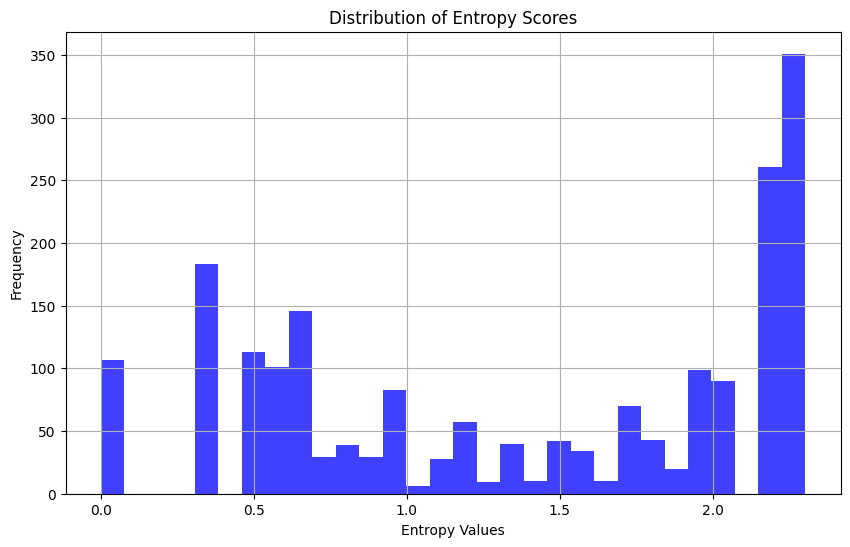

In [14]:
# Plot the entropy distribution
def plot_entropy_distribution(entropies):
    entropies_np = entropies.numpy()
    plt.figure(figsize=(10, 6))  # Set the figure size
    plt.hist(entropies_np, bins=30, alpha=0.75, color='blue')
    plt.title('Distribution of Entropy Scores')  # Title of the histogram
    plt.xlabel('Entropy Values')  # Label for the x-axis
    plt.ylabel('Frequency')  # Label for the y-axis
    plt.grid(True) 
    plt.show()

plot_entropy_distribution(entropy)

1.325730829570308

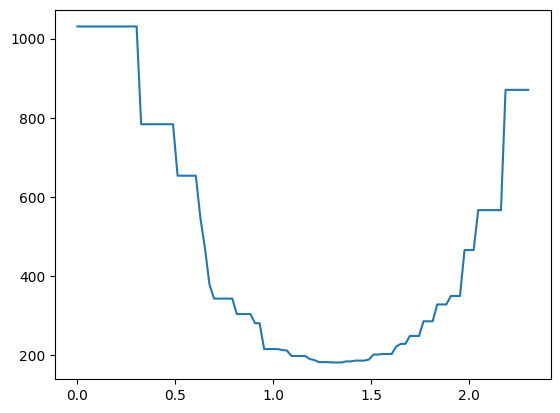

In [15]:
# Use best split approach (from Zebra notebook)
ents = entropy.numpy()
splits = np.linspace(1e-10, ents.max(), 100)
split_mses = []
for split in splits:
    low_idxs, high_idxs = ents < split, ents >= split

    low_mean = np.mean(ents[low_idxs])
    high_mean = np.mean(ents[high_idxs])

    mse = np.sum((ents[low_idxs] - low_mean)**2) + np.sum((ents[high_idxs] - high_mean)**2)
    mse = np.sum(mse)

    split_mses.append(mse)

split_mses = np.array(split_mses)

plt.plot(splits, split_mses)
splits[np.argmin(split_mses)]

In [16]:
def binarize_entropy(entropy, thres=0.0):  # 0.0 means even splits for normalized entropy scores
    """Binarize entropy scores into 0's and 1's"""
    binary_entropy = torch.full_like(entropy, -1, dtype=torch.float)
    binary_entropy[entropy < thres] = 0
    binary_entropy[entropy > thres] = 1

    return binary_entropy

bca_entropy = binarize_entropy(entropy, splits[np.argmin(split_mses)])
# bca_entropy = binarize_entropy(ca_entropy, 0.0)
print(f"Dummy accuracy: {max(torch.mean(bca_entropy).item(), 1-torch.mean(bca_entropy).item()):.4f}")

Dummy accuracy: 0.5335


In [51]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)

In [18]:
# Training with LR.
tblr_test_accs = []
tblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tblr_test_accs.append(test_acc)
    tblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.8528, AUROC: 0.9010
Training Loss: 0.2854, Validation Loss: 0.3544
Test Loss: 0.3380, Test Accuracy: 0.8750, AUROC: 0.8993
Training on Dataset 2/33
Validation Accuracy: 0.8556, AUROC: 0.9122
Training Loss: 0.2587, Validation Loss: 0.3401
Test Loss: 0.3207, Test Accuracy: 0.8850, AUROC: 0.9178
Training on Dataset 3/33
Validation Accuracy: 0.8667, AUROC: 0.9188
Training Loss: 0.2144, Validation Loss: 0.3282
Test Loss: 0.3244, Test Accuracy: 0.8800, AUROC: 0.9131
Training on Dataset 4/33
Validation Accuracy: 0.8583, AUROC: 0.9184
Training Loss: 0.1776, Validation Loss: 0.3315
Test Loss: 0.3312, Test Accuracy: 0.8850, AUROC: 0.9149
Training on Dataset 5/33
Validation Accuracy: 0.8583, AUROC: 0.9133
Training Loss: 0.1569, Validation Loss: 0.3498
Test Loss: 0.3519, Test Accuracy: 0.8850, AUROC: 0.9105
Training on Dataset 6/33
Validation Accuracy: 0.8667, AUROC: 0.9090
Training Loss: 0.1358, Validation Loss: 0.3782
Test Loss: 0.3573, Test Accura

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8722, AUROC: 0.9444
Training Loss: 0.0845, Validation Loss: 0.3064
Test Loss: 0.3564, Test Accuracy: 0.8750, AUROC: 0.9266
Training on Dataset 9/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8861, AUROC: 0.9406
Training Loss: 0.0687, Validation Loss: 0.3199
Test Loss: 0.3392, Test Accuracy: 0.8650, AUROC: 0.9357
Training on Dataset 10/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8833, AUROC: 0.9474
Training Loss: 0.0028, Validation Loss: 0.5458
Test Loss: 0.6717, Test Accuracy: 0.8650, AUROC: 0.9332
Training on Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8944, AUROC: 0.9483
Training Loss: 0.0024, Validation Loss: 0.5715
Test Loss: 0.6415, Test Accuracy: 0.8850, AUROC: 0.9396
Training on Dataset 33/33
Validation Accuracy: 0.8750, AUROC: 0.9475
Training Loss: 0.0013, Validation Loss: 0.6099
Test Loss: 0.6230, Test Accuracy: 0.8650, AUROC: 0.9471


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [52]:
print(f"LR on TBG embeddings and b-SE: best AUROC {max(tblr_test_aucs):.4f} at layer {np.argmax(tblr_test_aucs)+1}")

LR on TBG embeddings and b-SE: best AUROC 0.9494 at layer 13


In [53]:
def concat_Xs_and_ys(layer_range, X_trains, X_vals, X_tests, y_trains, y_vals, y_tests):
    X_train_cc = np.concatenate(np.array(X_trains)[layer_range], axis=1)
    X_val_cc = np.concatenate(np.array(X_vals)[layer_range], axis=1)
    X_test_cc = np.concatenate(np.array(X_tests)[layer_range], axis=1)
    y_train_cc = y_trains[layer_range[0]]
    y_val_cc = y_vals[layer_range[0]]
    y_test_cc = y_tests[layer_range[0]]
    return X_train_cc, X_val_cc, X_test_cc, y_train_cc, y_val_cc, y_test_cc

In [54]:
# Save models for testing on Accuracy
tblr_best_auc_indices = np.argsort(tblr_test_aucs)[::-1]

topktblr_test_accs = {}
topktblr_test_aucs = {}
topktblr_models = {}

for top_k in range(1, 10):
    indices = tblr_best_auc_indices[:top_k]
    print(f"Training on top-{top_k} Datasets indexed", list(indices+1))
    X_train, X_val, X_test, y_train, y_val, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {top_k} Datasets")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topktblr_test_accs[tuple(indices)] = test_acc
    topktblr_test_aucs[tuple(indices)] = test_auc
    topktblr_models[tuple(indices)] = model

Training on top-1 Datasets indexed [13]
Validation Accuracy: 0.8972, AUROC: 0.9417
Training Loss: 0.0272, Validation Loss: 0.4043
Test Loss: 0.3167, Test Accuracy: 0.8800, AUROC: 0.9494
Training on top-2 Datasets indexed [13, 21]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8833, AUROC: 0.9412
Training Loss: 0.0066, Validation Loss: 0.5165
Test Loss: 0.3979, Test Accuracy: 0.8850, AUROC: 0.9522
Training on top-3 Datasets indexed [13, 21, 20]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8806, AUROC: 0.9388
Training Loss: 0.0048, Validation Loss: 0.5770
Test Loss: 0.4350, Test Accuracy: 0.8900, AUROC: 0.9506
Training on top-4 Datasets indexed [13, 21, 20, 18]


...

Validation Accuracy: 0.8778, AUROC: 0.9423
Training Loss: 0.0040, Validation Loss: 0.5752
Test Loss: 0.4429, Test Accuracy: 0.8950, AUROC: 0.9519
Training on top-6 Datasets indexed [13, 21, 20, 18, 12, 33]
Validation Accuracy: 0.8972, AUROC: 0.9575
Training Loss: 0.0009, Validation Loss: 0.5139
Test Loss: 0.5574, Test Accuracy: 0.8850, AUROC: 0.9501
Training on top-7 Datasets indexed [13, 21, 20, 18, 12, 33, 15]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8972, AUROC: 0.9579
Training Loss: 0.0008, Validation Loss: 0.5269
Test Loss: 0.5806, Test Accuracy: 0.8850, AUROC: 0.9494
Training on top-8 Datasets indexed [13, 21, 20, 18, 12, 33, 15, 14]
Validation Accuracy: 0.9000, AUROC: 0.9590
Training Loss: 0.0008, Validation Loss: 0.5241
Test Loss: 0.5718, Test Accuracy: 0.8750, AUROC: 0.9506
Training on top-9 Datasets indexed [13, 21, 20, 18, 12, 33, 15, 14, 11]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8972, AUROC: 0.9595
Training Loss: 0.0008, Validation Loss: 0.5096
Test Loss: 0.5557, Test Accuracy: 0.8750, AUROC: 0.9510


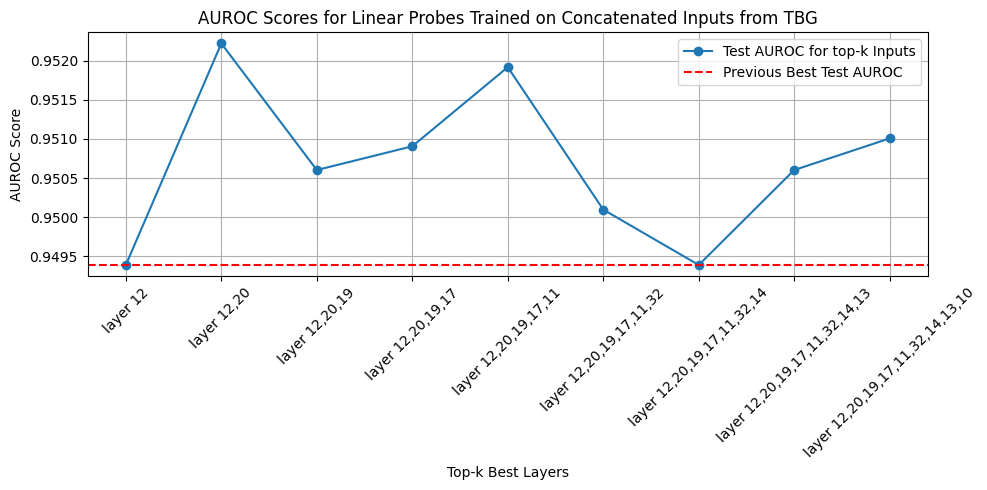

0.9522218848061544


In [55]:
# Plot the concat-ed trained AUROC scores and the previous best score
plot_metrics_w_constant(max(tblr_test_aucs), topktblr_test_aucs, 'TBG')
print(max(topktblr_test_aucs.values()))

### Explore Second Last generated Token (SLT)


In [57]:
sec_last_tok_dataset = torch.stack([record['most_likely_answer']['emb_tok_before_eos'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
print(sec_last_tok_dataset.shape)

torch.Size([2000, 33, 4096])


In [21]:
sec_last_tok_dataset.transpose(0, 1).shape

torch.Size([33, 2000, 4096])

In [22]:
slt_layered_datasets = sec_last_tok_dataset.transpose(0, 1)
print(slt_layered_datasets.shape, slt_layered_datasets.dtype)

torch.Size([33, 2000, 4096]) torch.float32


In [18]:
# We may want to drop the first layer due to its homogeneity in values.
# print(slt_layered_datasets[0], slt_layered_datasets[0].shape)
# slt_layered_datasets = slt_layered_datasets[1:]

In [58]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)

In [24]:
# Training with LR.
sblr_test_accs = []
sblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sblr_test_accs.append(test_acc)
    sblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.5306, AUROC: 0.5000
Training Loss: 0.6912, Validation Loss: 0.6913
Test Loss: 0.6882, Test Accuracy: 0.5550, AUROC: 0.5000
Training on Dataset 2/33
Validation Accuracy: 0.6722, AUROC: 0.7707
Training Loss: 0.6569, Validation Loss: 0.6563
Test Loss: 0.6565, Test Accuracy: 0.6800, AUROC: 0.7455
Training on Dataset 3/33
Validation Accuracy: 0.7278, AUROC: 0.8170
Training Loss: 0.6190, Validation Loss: 0.6174
Test Loss: 0.6097, Test Accuracy: 0.7550, AUROC: 0.8424
Training on Dataset 4/33
Validation Accuracy: 0.7944, AUROC: 0.8708
Training Loss: 0.5307, Validation Loss: 0.5377
Test Loss: 0.5212, Test Accuracy: 0.8200, AUROC: 0.8917
Training on Dataset 5/33
Validation Accuracy: 0.8583, AUROC: 0.9027
Training Loss: 0.4374, Validation Loss: 0.4521
Test Loss: 0.4395, Test Accuracy: 0.8650, AUROC: 0.8989
Training on Dataset 6/33
Validation Accuracy: 0.8667, AUROC: 0.9136
Training Loss: 0.3643, Validation Loss: 0.3843
Test Loss: 0.3691, Test Accura

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8694, AUROC: 0.9423
Training Loss: 0.1117, Validation Loss: 0.3058
Test Loss: 0.2604, Test Accuracy: 0.8850, AUROC: 0.9487
Training on Dataset 12/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8806, AUROC: 0.9374
Training Loss: 0.0878, Validation Loss: 0.3344
Test Loss: 0.2627, Test Accuracy: 0.8900, AUROC: 0.9498
Training on Dataset 13/33
Validation Accuracy: 0.8722, AUROC: 0.9367
Training Loss: 0.0685, Validation Loss: 0.3596
Test Loss: 0.2903, Test Accuracy: 0.8850, AUROC: 0.9464
Training on Dataset 14/33


...

Validation Accuracy: 0.8750, AUROC: 0.9422
Training Loss: 0.0485, Validation Loss: 0.3636
Test Loss: 0.2900, Test Accuracy: 0.8950, AUROC: 0.9542
Training on Dataset 15/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8806, AUROC: 0.9466
Training Loss: 0.0344, Validation Loss: 0.3753
Test Loss: 0.3210, Test Accuracy: 0.9000, AUROC: 0.9518
Training on Dataset 16/33
Validation Accuracy: 0.8722, AUROC: 0.9526
Training Loss: 0.0214, Validation Loss: 0.3830
Test Loss: 0.4006, Test Accuracy: 0.8750, AUROC: 0.9464
Training on Dataset 17/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8806, AUROC: 0.9524
Training Loss: 0.0162, Validation Loss: 0.3957
Test Loss: 0.3827, Test Accuracy: 0.9000, AUROC: 0.9503
Training on Dataset 18/33
Validation Accuracy: 0.8667, AUROC: 0.9537
Training Loss: 0.0098, Validation Loss: 0.4163
Test Loss: 0.4155, Test Accuracy: 0.8850, AUROC: 0.9510
Training on Dataset 19/33
Validation Accuracy: 0.8889, AUROC: 0.9515
Training Loss: 0.0075, Validation Loss: 0.4543
Test Loss: 0.4089, Test Accuracy: 0.9000, AUROC: 0.9559
Training on Dataset 20/33
Validation Accuracy: 0.8778, AUROC: 0.9525
Training Loss: 0.0058, Validation Loss: 0.4900
Test Loss: 0.4116, Test Accuracy: 0.9000, AUROC: 0.9590
Training on Dataset 21/33
Validation Accuracy: 0.8833, AUROC: 0.9528
Training Loss: 0.0042, Validation Loss: 0.5077
Test Loss: 0.4389, Test Accuracy: 0.9000, AUROC: 0.9602
Training on Dataset 22/33
Validation Accuracy: 0.8861, AUROC: 0.9575
Training Loss: 0.0031, Validation Loss: 0.4904
Test Loss: 0.4235, Test Accuracy: 0.8950, AUROC: 0

In [25]:
print(f"LR on SLT embeddings and b-SE: best AUROC {max(sblr_test_aucs):.4f} at layer {np.argmax(sblr_test_aucs)+1}")

LR on SLT embeddings and b-SE: best AUROC 0.9769 at layer 26


In [59]:
# Select best top-k layers 
sblr_best_auc_indices = np.argsort(sblr_test_aucs)[::-1]

topksblr_test_accs = {}
topksblr_test_aucs = {}
topksblr_models = {}

for top_k in range(1, 10):
    indices = sblr_best_auc_indices[:top_k]
    print(f"Training on top-{top_k} Datasets indexed", list(indices+1))
    X_train, X_val, X_test, y_train, y_val, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {top_k} Datasets")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topksblr_test_accs[tuple(indices)] = test_acc
    topksblr_test_aucs[tuple(indices)] = test_auc
    topksblr_models[tuple(indices)] = model

Training on top-1 Datasets indexed [26]
Validation Accuracy: 0.9167, AUROC: 0.9630
Training Loss: 0.0014, Validation Loss: 0.4583
Test Loss: 0.3442, Test Accuracy: 0.9100, AUROC: 0.9769
Training on top-2 Datasets indexed [26, 25]
Validation Accuracy: 0.9111, AUROC: 0.9639
Training Loss: 0.0009, Validation Loss: 0.4688
Test Loss: 0.3579, Test Accuracy: 0.9200, AUROC: 0.9771
Training on top-3 Datasets indexed [26, 25, 33]
Validation Accuracy: 0.9167, AUROC: 0.9668
Training Loss: 0.0005, Validation Loss: 0.4823
Test Loss: 0.3224, Test Accuracy: 0.9400, AUROC: 0.9821
Training on top-4 Datasets indexed [26, 25, 33, 27]
Validation Accuracy: 0.9194, AUROC: 0.9685
Training Loss: 0.0003, Validation Loss: 0.4722
Test Loss: 0.3316, Test Accuracy: 0.9400, AUROC: 0.9822
Training on top-5 Datasets indexed [26, 25, 33, 27, 30]
Validation Accuracy: 0.9222, AUROC: 0.9677
Training Loss: 0.0003, Validation Loss: 0.5227
Test Loss: 0.3849, Test Accuracy: 0.9450, AUROC: 0.9798
Training on top-6 Datasets ind

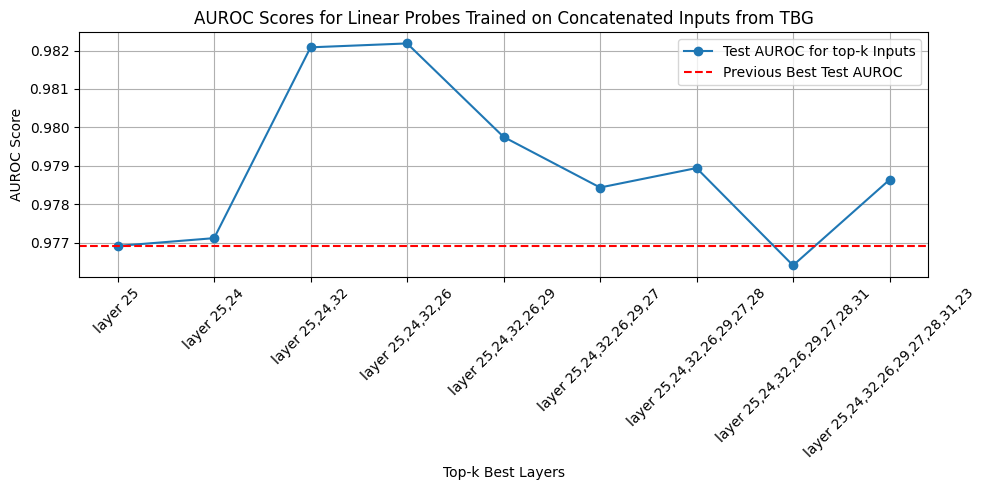

0.9821844316226338


In [61]:
# Plot the concat-ed trained AUROC scores and the previous best score
plot_metrics_w_constant(max(sblr_test_aucs), topksblr_test_aucs, 'TBG')
print(max(topksblr_test_aucs.values()))

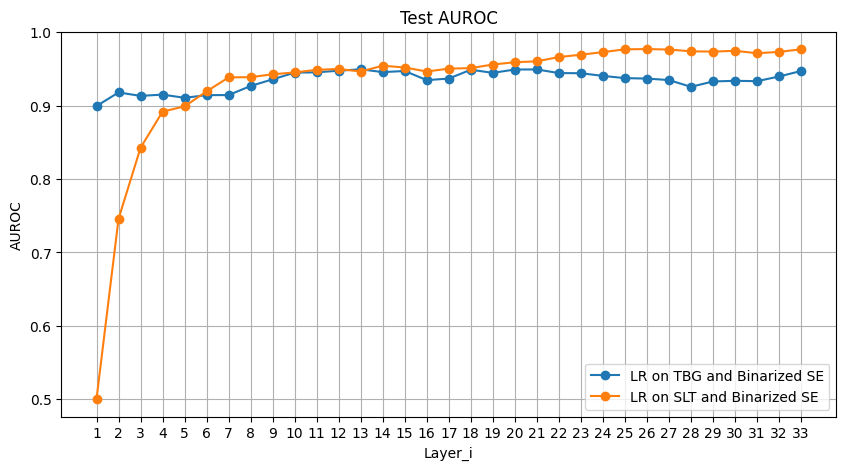

TBG: max AUROC for LR trained and tested on Binarized SE: 0.9494 at 13 layer
SLT: max AUROC for LR trained and tested on Binarized SE: 0.9769 at 26 layer


In [62]:
plot_1d_metrics([tblr_test_aucs, sblr_test_aucs], ['LR on TBG and Binarized SE', 'LR on SLT and Binarized SE'], 'AUROC')
print(f"TBG: max AUROC for LR trained and tested on Binarized SE: {max(tblr_test_aucs):.4f} at {np.argmax(tblr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained and tested on Binarized SE: {max(sblr_test_aucs):.4f} at {np.argmax(sblr_test_aucs)+1} layer")

## Use Linear Probe for Predicting Correctness of Generated Answers (or Accuracy)

It would be interesting to see how linear probes perform at predicting accuracy obtained from using semantic entropy at selecting the most probable answer (true or false), as indicated in the `compute_uncertainty_measures.py` (_# For the semantic uncertainties, we can also change the prediction, by first selecting the semantic cluster with the highest probability, and then selecting the generation with the highest probability within that cluster._)

We will use logistic regression for this task, as for the binarized entropy prediction task.

### Token Before first Generation (TBG)

In [26]:
accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in generations.values()])
print(accuracies.shape, accuracies[:10])  # "Accuracies" are binary. Classification task.

torch.Size([2000]) tensor([0., 1., 1., 0., 0., 0., 0., 1., 0., 1.])


In [27]:
# Prepare X's and y's for sklearn LR model.
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, accuracies, total_size)

In [28]:
# Dummy accuracy:
print(f"Dummy accuracy: {max(np.mean(y_tests), 1-np.mean(y_tests)):.4f}")

Dummy accuracy: 0.5550


In [29]:
# Training Loops (LR)
talr_test_accs = []
talr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    talr_test_accs.append(test_acc)
    talr_test_aucs.append(test_auc)

Training on TBG-Acc Dataset 1/33
Validation Accuracy: 0.7500, AUROC: 0.7707
Training Loss: 0.4989, Validation Loss: 0.5548
Test Loss: 0.5265, Test Accuracy: 0.7850, AUROC: 0.7863
Training on TBG-Acc Dataset 2/33
Validation Accuracy: 0.7694, AUROC: 0.7871
Training Loss: 0.4690, Validation Loss: 0.5414
Test Loss: 0.5274, Test Accuracy: 0.7700, AUROC: 0.8059
Training on TBG-Acc Dataset 3/33
Validation Accuracy: 0.7611, AUROC: 0.7719
Training Loss: 0.4085, Validation Loss: 0.5584
Test Loss: 0.5463, Test Accuracy: 0.7450, AUROC: 0.8109
Training on TBG-Acc Dataset 4/33
Validation Accuracy: 0.7639, AUROC: 0.7973
Training Loss: 0.3521, Validation Loss: 0.5465
Test Loss: 0.5508, Test Accuracy: 0.7600, AUROC: 0.7913
Training on TBG-Acc Dataset 5/33
Validation Accuracy: 0.7500, AUROC: 0.7910
Training Loss: 0.3210, Validation Loss: 0.5690
Test Loss: 0.5795, Test Accuracy: 0.7700, AUROC: 0.7836
Training on TBG-Acc Dataset 6/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7667, AUROC: 0.8001
Training Loss: 0.2916, Validation Loss: 0.5739
Test Loss: 0.5889, Test Accuracy: 0.7500, AUROC: 0.7906
Training on TBG-Acc Dataset 7/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7694, AUROC: 0.7984
Training Loss: 0.2544, Validation Loss: 0.5973
Test Loss: 0.5820, Test Accuracy: 0.7650, AUROC: 0.8054
Training on TBG-Acc Dataset 8/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7361, AUROC: 0.7772
Training Loss: 0.0072, Validation Loss: 2.1856
Test Loss: 1.5222, Test Accuracy: 0.7500, AUROC: 0.8330
Training on TBG-Acc Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7028, AUROC: 0.7648
Training Loss: 0.0050, Validation Loss: 2.4456
Test Loss: 1.5585, Test Accuracy: 0.7250, AUROC: 0.8355
Training on TBG-Acc Dataset 33/33
Validation Accuracy: 0.7306, AUROC: 0.7713
Training Loss: 0.0163, Validation Loss: 2.4978
Test Loss: 1.9223, Test Accuracy: 0.7450, AUROC: 0.8089


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


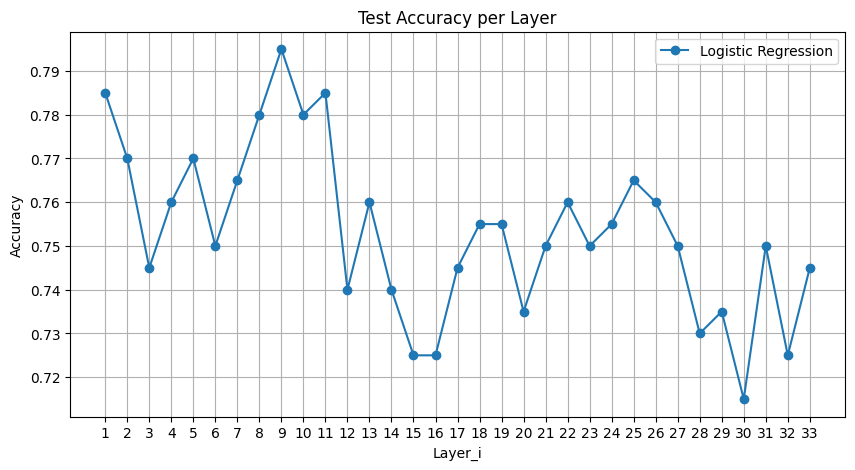

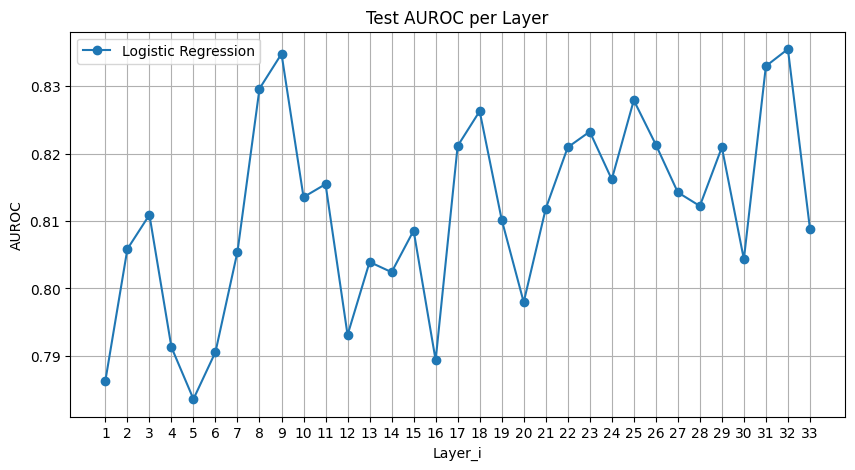

In [30]:
plot_1d_metrics([talr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([talr_test_aucs], ['Logistic Regression'], 'AUROC')

In [31]:
print(f"LR on TBG embeddings and Accuracy: best AUROC {max(talr_test_aucs):.4f} at layer {np.argmax(talr_test_aucs)+1}")

LR on TBG embeddings and Accuracy: best AUROC 0.8355 at layer 32


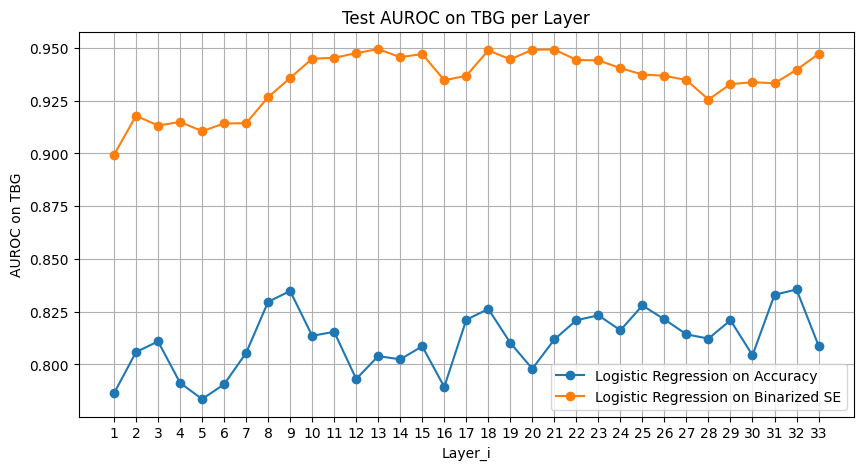

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.8355 at 32 layer
TBG: max AUROC for LR trained on Binary SE, tested on Binary SE: 0.9494 at 13 layer


In [47]:
plot_1d_metrics([talr_test_aucs, tblr_test_aucs], ['Logistic Regression on Accuracy', 'Logistic Regression on Binarized SE'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Binary SE: {max(tblr_test_aucs):.4f} at {np.argmax(tblr_test_aucs)+1} layer")

In [32]:
# Data for SLT embeddings
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, accuracies, total_size)

In [33]:
# Training with LR.
salr_test_accs = []
salr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    salr_test_accs.append(test_acc)
    salr_test_aucs.append(test_auc)

Training on SLT-Acc Dataset 1/33
Validation Accuracy: 0.5472, AUROC: 0.5000
Training Loss: 0.6825, Validation Loss: 0.6900
Test Loss: 0.6877, Test Accuracy: 0.5550, AUROC: 0.5000
Training on SLT-Acc Dataset 2/33
Validation Accuracy: 0.5472, AUROC: 0.6537
Training Loss: 0.6677, Validation Loss: 0.6786
Test Loss: 0.6748, Test Accuracy: 0.5550, AUROC: 0.6625
Training on SLT-Acc Dataset 3/33
Validation Accuracy: 0.5694, AUROC: 0.6765
Training Loss: 0.6470, Validation Loss: 0.6617
Test Loss: 0.6513, Test Accuracy: 0.5750, AUROC: 0.7246
Training on SLT-Acc Dataset 4/33
Validation Accuracy: 0.6611, AUROC: 0.7167
Training Loss: 0.6117, Validation Loss: 0.6343
Test Loss: 0.6193, Test Accuracy: 0.6950, AUROC: 0.7619
Training on SLT-Acc Dataset 5/33
Validation Accuracy: 0.7278, AUROC: 0.7492
Training Loss: 0.5714, Validation Loss: 0.6005
Test Loss: 0.5730, Test Accuracy: 0.7550, AUROC: 0.7990
Training on SLT-Acc Dataset 6/33
Validation Accuracy: 0.7333, AUROC: 0.7733
Training Loss: 0.5351, Valida

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7639, AUROC: 0.8115
Training Loss: 0.4382, Validation Loss: 0.5294
Test Loss: 0.4807, Test Accuracy: 0.8150, AUROC: 0.8491
Training on SLT-Acc Dataset 9/33
Validation Accuracy: 0.7583, AUROC: 0.8128
Training Loss: 0.4000, Validation Loss: 0.5298
Test Loss: 0.4767, Test Accuracy: 0.7900, AUROC: 0.8460
Training on SLT-Acc Dataset 10/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7500, AUROC: 0.8187
Training Loss: 0.3687, Validation Loss: 0.5297
Test Loss: 0.4678, Test Accuracy: 0.7950, AUROC: 0.8606
Training on SLT-Acc Dataset 11/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7389, AUROC: 0.8009
Training Loss: 0.0043, Validation Loss: 1.8951
Test Loss: 1.8561, Test Accuracy: 0.7950, AUROC: 0.8331
Training on SLT-Acc Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7528, AUROC: 0.8043
Training Loss: 0.0038, Validation Loss: 1.8149
Test Loss: 1.7280, Test Accuracy: 0.7900, AUROC: 0.8414
Training on SLT-Acc Dataset 33/33
Validation Accuracy: 0.7417, AUROC: 0.7803
Training Loss: 0.0154, Validation Loss: 2.2068
Test Loss: 1.9109, Test Accuracy: 0.8150, AUROC: 0.8397


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


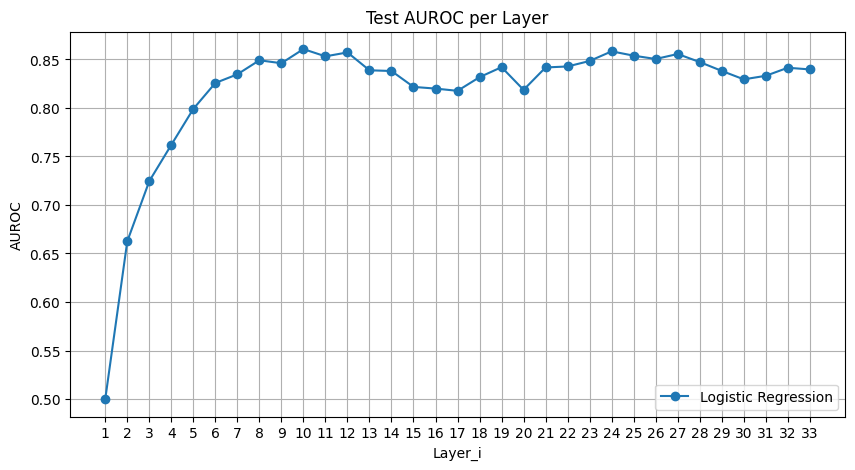

In [35]:
# plot_1d_metrics([salr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([salr_test_aucs], ['Logistic Regression'], 'AUROC')

In [36]:
print(f"LR on SLT embeddings and Accuracy: best AUROC {max(salr_test_aucs):.4f} at layer {np.argmax(salr_test_aucs)+1}")

LR on SLT embeddings and Accuracy: best AUROC 0.8606 at layer 10


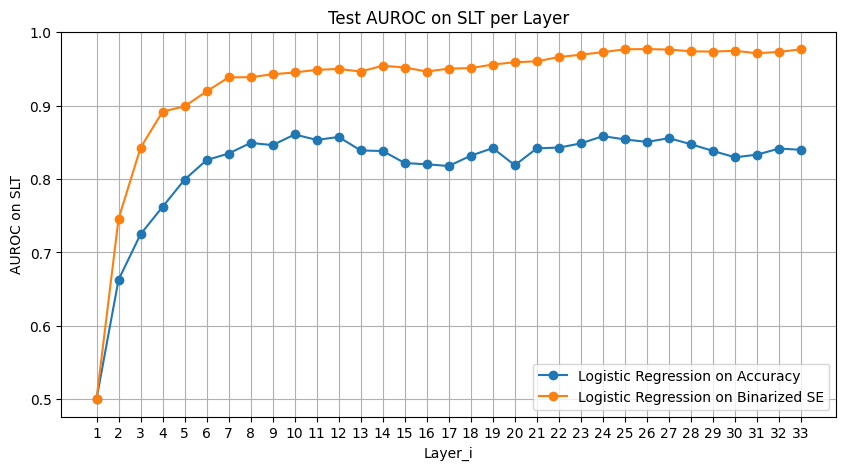

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.8606 at 10 layer
SLT: max AUROC for LR trained on Binary SE, tested on Binary SE: 0.9769 at 26 layer


In [46]:
plot_1d_metrics([salr_test_aucs, sblr_test_aucs], ['Logistic Regression on Accuracy', 'Logistic Regression on Binarized SE'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Binary SE: {max(sblr_test_aucs):.4f} at {np.argmax(sblr_test_aucs)+1} layer")

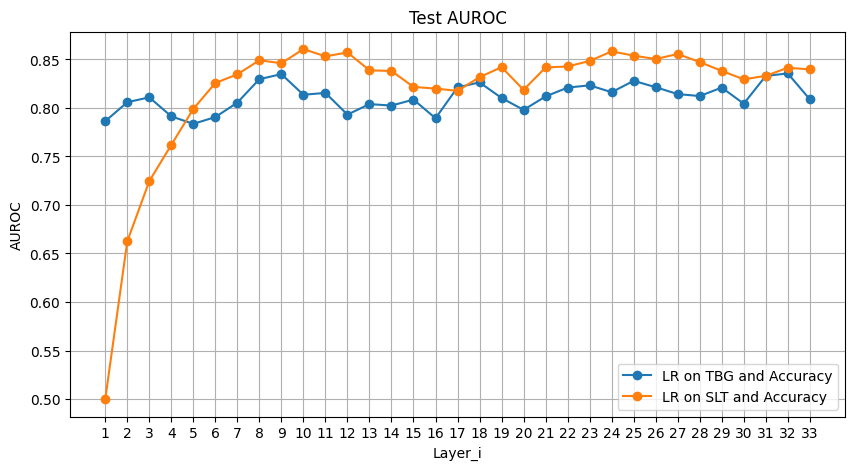

TBG: max AUROC for LR trained and tested on Accuracy: 0.8355 at 32 layer
SLT: max AUROC for LR trained and tested on Accuracy: 0.8606 at 10 layer


In [63]:
plot_1d_metrics([talr_test_aucs, salr_test_aucs], ['LR on TBG and Accuracy', 'LR on SLT and Accuracy'], 'AUROC')
print(f"TBG: max AUROC for LR trained and tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained and tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")

## Use Classifier for Binary SE for Predicting LLM Accuracy

We want to show that models trained on binary SE are more generalizable to new datasets when predicting their generation correctness.

In [64]:
# Test with accuracy test set (with the same random seed to ensure no data leakage)
# We should reverse the accuracy due to negative R.
r_accuracies = 1 - accuracies

X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, r_accuracies, total_size)

In [41]:
# Training Loops (LR)
tablr_test_accs = []
tablr_test_aucs = []
tablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tablr_test_accs.append(test_acc)
    tablr_test_aucs.append(test_auc)
    tablr_trained_models.append(model)

Training on TBG Dataset 1/33
Validation Accuracy: 0.8528, AUROC: 0.9010
Training Loss: 0.2854, Validation Loss: 0.3544
Test Loss: 0.5552, Test Accuracy: 0.7850, AUROC: 0.8036
Training on TBG Dataset 2/33
Validation Accuracy: 0.8556, AUROC: 0.9122
Training Loss: 0.2587, Validation Loss: 0.3401
Test Loss: 0.5641, Test Accuracy: 0.7850, AUROC: 0.8249
Training on TBG Dataset 3/33
Validation Accuracy: 0.8667, AUROC: 0.9188
Training Loss: 0.2144, Validation Loss: 0.3282
Test Loss: 0.5953, Test Accuracy: 0.7900, AUROC: 0.8151
Training on TBG Dataset 4/33
Validation Accuracy: 0.8583, AUROC: 0.9184
Training Loss: 0.1776, Validation Loss: 0.3315
Test Loss: 0.6044, Test Accuracy: 0.7850, AUROC: 0.8181
Training on TBG Dataset 5/33
Validation Accuracy: 0.8583, AUROC: 0.9133
Training Loss: 0.1569, Validation Loss: 0.3498
Test Loss: 0.6453, Test Accuracy: 0.7850, AUROC: 0.8133
Training on TBG Dataset 6/33
Validation Accuracy: 0.8667, AUROC: 0.9090
Training Loss: 0.1358, Validation Loss: 0.3782
Test L

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8722, AUROC: 0.9444
Training Loss: 0.0845, Validation Loss: 0.3064
Test Loss: 0.8252, Test Accuracy: 0.7850, AUROC: 0.7977
Training on TBG Dataset 9/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8861, AUROC: 0.9406
Training Loss: 0.0687, Validation Loss: 0.3199
Test Loss: 0.8554, Test Accuracy: 0.7750, AUROC: 0.8152
Training on TBG Dataset 10/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8833, AUROC: 0.9474
Training Loss: 0.0028, Validation Loss: 0.5458
Test Loss: 2.0040, Test Accuracy: 0.7550, AUROC: 0.8097
Training on TBG Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8944, AUROC: 0.9483
Training Loss: 0.0024, Validation Loss: 0.5715
Test Loss: 2.1012, Test Accuracy: 0.7650, AUROC: 0.8083
Training on TBG Dataset 33/33
Validation Accuracy: 0.8750, AUROC: 0.9475
Training Loss: 0.0013, Validation Loss: 0.6099
Test Loss: 2.0440, Test Accuracy: 0.7650, AUROC: 0.8084


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


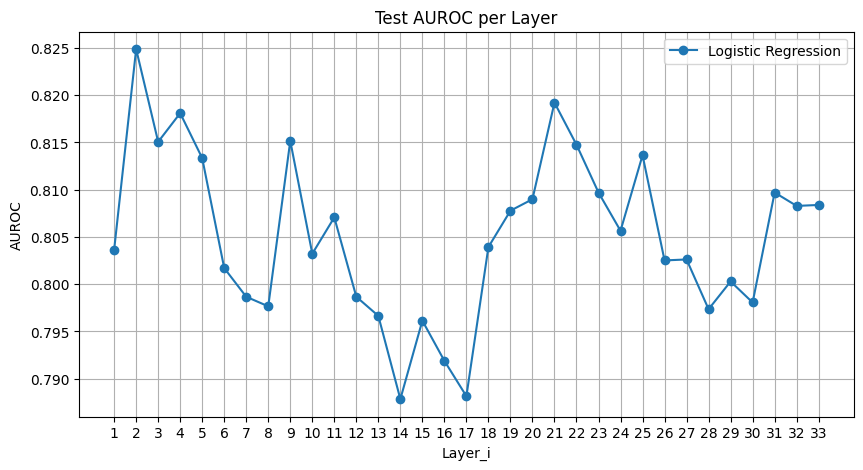

In [39]:
# plot_1d_metrics([tablr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([tablr_test_aucs], ['Logistic Regression'], 'AUROC')

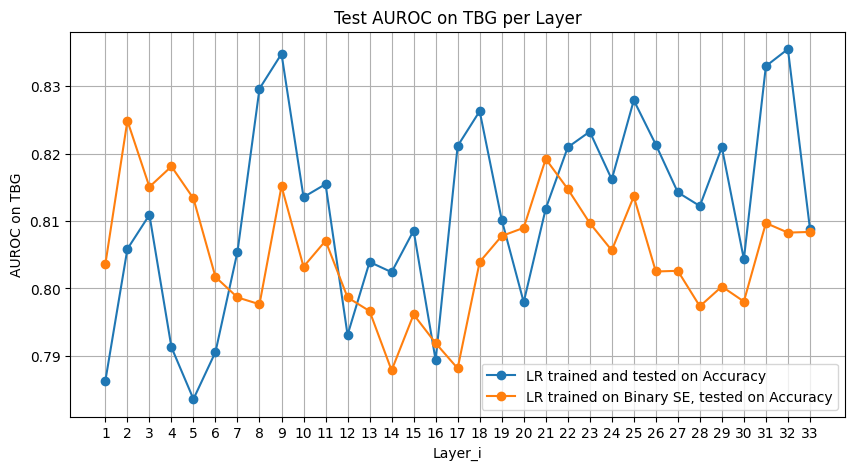

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.8355 at 32 layer
TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.8249 at 2 layer


In [40]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([talr_test_aucs, tablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(tablr_test_aucs):.4f} at {np.argmax(tablr_test_aucs)+1} layer")

Now we test on SLT embeddings.

In [42]:
X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(slt_layered_datasets, r_accuracies, total_size)

In [43]:
# Training Loops (LR)
sablr_test_accs = []
sablr_test_aucs = []
sablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sablr_test_accs.append(test_acc)
    sablr_test_aucs.append(test_auc)
    sablr_trained_models.append(model)

Training on SLT Dataset 1/33
Validation Accuracy: 0.5306, AUROC: 0.5000
Training Loss: 0.6912, Validation Loss: 0.6913
Test Loss: 0.6882, Test Accuracy: 0.5550, AUROC: 0.5000
Training on SLT Dataset 2/33
Validation Accuracy: 0.6722, AUROC: 0.7707
Training Loss: 0.6569, Validation Loss: 0.6563
Test Loss: 0.6723, Test Accuracy: 0.6100, AUROC: 0.6312
Training on SLT Dataset 3/33
Validation Accuracy: 0.7278, AUROC: 0.8170
Training Loss: 0.6190, Validation Loss: 0.6174
Test Loss: 0.6443, Test Accuracy: 0.6850, AUROC: 0.7155
Training on SLT Dataset 4/33
Validation Accuracy: 0.7944, AUROC: 0.8708
Training Loss: 0.5307, Validation Loss: 0.5377
Test Loss: 0.6055, Test Accuracy: 0.7300, AUROC: 0.7471
Training on SLT Dataset 5/33
Validation Accuracy: 0.8583, AUROC: 0.9027
Training Loss: 0.4374, Validation Loss: 0.4521
Test Loss: 0.5546, Test Accuracy: 0.7750, AUROC: 0.7695
Training on SLT Dataset 6/33
Validation Accuracy: 0.8667, AUROC: 0.9136
Training Loss: 0.3643, Validation Loss: 0.3843
Test L

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8694, AUROC: 0.9423
Training Loss: 0.1117, Validation Loss: 0.3058
Test Loss: 0.7868, Test Accuracy: 0.7650, AUROC: 0.8198
Training on SLT Dataset 12/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8806, AUROC: 0.9374
Training Loss: 0.0878, Validation Loss: 0.3344
Test Loss: 0.9001, Test Accuracy: 0.7600, AUROC: 0.8189
Training on SLT Dataset 13/33
Validation Accuracy: 0.8722, AUROC: 0.9367
Training Loss: 0.0685, Validation Loss: 0.3596
Test Loss: 0.9572, Test Accuracy: 0.7550, AUROC: 0.8187
Training on SLT Dataset 14/33


...

Validation Accuracy: 0.8750, AUROC: 0.9422
Training Loss: 0.0485, Validation Loss: 0.3636
Test Loss: 1.0545, Test Accuracy: 0.7450, AUROC: 0.8175
Training on SLT Dataset 15/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8806, AUROC: 0.9466
Training Loss: 0.0344, Validation Loss: 0.3753
Test Loss: 1.1677, Test Accuracy: 0.7600, AUROC: 0.8232
Training on SLT Dataset 16/33
Validation Accuracy: 0.8722, AUROC: 0.9526
Training Loss: 0.0214, Validation Loss: 0.3830
Test Loss: 1.3145, Test Accuracy: 0.7550, AUROC: 0.8209
Training on SLT Dataset 17/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8806, AUROC: 0.9524
Training Loss: 0.0162, Validation Loss: 0.3957
Test Loss: 1.3493, Test Accuracy: 0.7700, AUROC: 0.8259
Training on SLT Dataset 18/33
Validation Accuracy: 0.8667, AUROC: 0.9537
Training Loss: 0.0098, Validation Loss: 0.4163
Test Loss: 1.4360, Test Accuracy: 0.7650, AUROC: 0.8326
Training on SLT Dataset 19/33
Validation Accuracy: 0.8889, AUROC: 0.9515
Training Loss: 0.0075, Validation Loss: 0.4543
Test Loss: 1.4492, Test Accuracy: 0.7800, AUROC: 0.8425
Training on SLT Dataset 20/33
Validation Accuracy: 0.8778, AUROC: 0.9525
Training Loss: 0.0058, Validation Loss: 0.4900
Test Loss: 1.6259, Test Accuracy: 0.7500, AUROC: 0.8359
Training on SLT Dataset 21/33
Validation Accuracy: 0.8833, AUROC: 0.9528
Training Loss: 0.0042, Validation Loss: 0.5077
Test Loss: 1.7172, Test Accuracy: 0.7400, AUROC: 0.8379
Training on SLT Dataset 22/33
Validation Accuracy: 0.8861, AUROC: 0.9575
Training Loss: 0.0031, Validation Loss: 0.4904
Test Loss: 1.8794, Test Accura

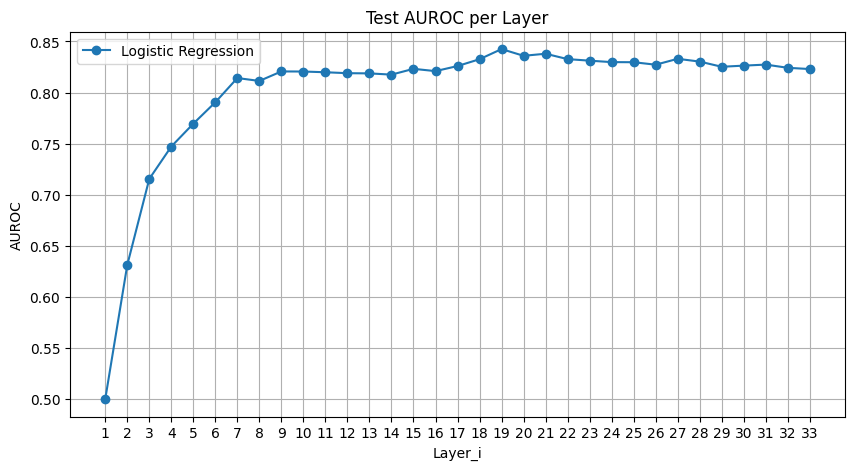

In [44]:
# plot_1d_metrics([sablr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([sablr_test_aucs], ['Logistic Regression'], 'AUROC')

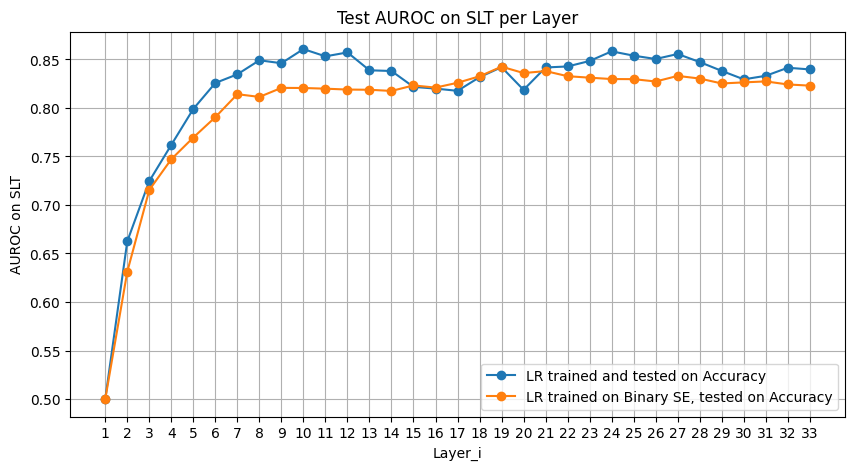

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.8606 at 10 layer
SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.8425 at 19 layer


In [45]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([salr_test_aucs, sablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(sablr_test_aucs):.4f} at {np.argmax(sablr_test_aucs)+1} layer")